# Backpropagation Pooling

Now that we have incorporated the forward passes of the pooling layer, we need to introduce the backwards pass of the pooling layer before we can tackle the backwards pass of the convolutional layer. 

Typically, we'll calculate the derivative of the output activation function along with the loss function. In this case, we'd use categorical cross entropy to get our deriviative saving on resources. Once we obtain our derivative, we need to multiply this result along with the derivative of the pooling layer and pass this result further along into our model.

In the context of the weighted sum of a dense layer. We would like to calculate the partial derivative of the sum function, and by using the chain rule multiply this by its respective output activation function. 
Since the input of the pooling layer was denoted by 
```python
Inputs should be of shape (S, H_in, W_in, C = D_in) 
self.output = np.zeros(shape = (S, H_out, W_out, C))
```
We'll pass in a dvalues of the same shape as output dvalues will have shape (S, H_out, W_out, C) while dinputs will have shape (S, H_in, W_in, C = D_in )

For the pooling layer, the dinputs will be a gradient of the loss function wrt. the pooling layers inputs (S, H_in, W_in, C = D_in).

Again, during the forwards pass, the incorporation of max pooling used the following formula:
$$
P_{\text{max}}(i, j) = \max_{0 \le a < n, \, 0 \le b < n} F(i \cdot s + a, \, j \cdot s + b)
$$
Where:
* $P_{max} (i, j)\text{: the pooled value at position } (i,j)$
* $F$: the input feature map
* $n$: the pooling windows size (e.g, 2x2, 3x3, etc)
* $s$: the stride
* $a, b$: iterate over the window dimensions

I'll slightly repurpose the max pooling operation into a mathmatical version suitable for backpropagation. 
Now, given:

* Input tensor
$$
X \in \mathbb{R}^{S, H_{in}, W_{in}, C}
$$
* Output tensor
$$
Y = \text{Pool}(X) \in \mathbb{R}^{S, H_{out}, W_{out}, C}
$$
* Filter sizes
$$
(f_H, f_W)
$$
* Stride 
$$
(s_H, s_W)
$$

* Pooling type: Max pooling (with valid padding)

* At each spatial position (h, w) and channel c,
$$
Y_{s, h, w, c} = \max_{ (i,j) \in \text{window}(h, w)} X(s, h \cdot s_H + i, w \cdot s_W + j, c)
$$

  where the window corresponds to $ h' = h \cdot s_H, \quad w' = w \cdot s_W $

For us, In order to map our dimension size from (S, H_out, W_out, C) we need to know where each of the *max* indicies were in each of the *windows* at we created. To do this, we'll use the np.argmax function which returns the indicies of where each of our max inputs are. To save some time, we'll compute this during the forward pass of the our Pooling layer. 

```python 

if self.pooling_type == "max":
    #keep the logic for taking the max at every window 
    pooled = patches.max(axis = (3, 4), keepdims = True ) 
    #We'll reshape the window to become a 1d array of size fH * fW
    patches_reshaped = patches.reshape(S, H_out, W_out, fH * fW, C)
    
    #take the max of that flattened set of arrays at axis 3 now. 
    flat_indicies = patches.reshaped.argmax(axis = 3)

    #Now, we'll convert those flat indicies back to row col coordinates withing each
    #(fH, fW) patch
    max_rows, max_cols = np.unravel_index(flat_indicies, (fH, fW)) 

    #what we'll store for backpropagation 
    self.max_indicies = (max_rows, max_cols) 
            
```

* For the backwards pass we'll recieve the gradient
$$
\frac{\partial L}{\partial Y} = dY \in \mathbb{R}^{S, H_{out}, W_{out}, C}
$$

This partial derivative will be our gradient of the loss L wrt. each output value. In other words, we want the graident of the loss *L* with repsect to **each element** of the input tensor *X*. Since we have already pooled our original image, we would like to "unpool" the gradient, that is to map each value of *dY* back to the locaiton in *X* that orginally produced that maximum. 

$$
\frac{\partial L}{\partial X} = dX
$$
In words
* $dX$: gradient flowing out of the pooling layer (same shape as X (s, H_in, W_in, C))
* $\partial L$: partial derivative of our loss function 
*To compute $dX$, we scatter the gradients from $dY$ back to their respective max indicies (we'll use self.max_indicies). Remember, during the forward pass other elements of the pooling window will get set to zero, because their values did not influence the output value. Only the max had influence over our loss L. 
If we had passed in inputs into the forward pass as a matrix
$$
\begin{bmatrix}
 1 & 2 & 3 & 4 \\
 4 & 5 & 6 & 5 \\
 7 & 8 & 9 & 6 \\
 8 & 7 & 6 & 5
 \end{bmatrix}
$$  
We'd then perform the max pooling, lets assume we only wanted to take take the max of a 2x2 window at inputs[0, 0]. So
$$
\begin{bmatrix}
1 & 2 \\
4 & 5 
\end{bmatrix} = 5
$$
Once we perform backpropogation, this point should then become 
$$
\begin{bmatrix}
0 & 0 \\
0 & 5 
\end{bmatrix}
$$
With our final dX becomming (assuming we took the max of all 4 windows in this example)
$
\begin{bmatrix}
 0 & 0 & 0 & 0 \\
 0 & 5 & 6 & 0 \\
 0 & 8 & 9 & 0 \\
 0 & 0 & 0 & 0
 \end{bmatrix}
$

Again, we'll use the max_indicies as well as dvalues to convert our pooled batch of images back to shape (S, H_in, W_in, C = D_in), and whatever max value we had we'll keep that, otherwise we'll set the rest of the values inside the window as zero. 

# np.add.at
Since we already know how the algorithm works, we now need to implement this algorithm. We have a problem where if we wanted to add something to our empty matrix of zeros created for dinputs, we still need to add something at those windows. 
In a 2d array, if we had the array
```python
a = np.array(([1, 2, 3, 4]))
```
If we wanted a powerful way of adding things to arrays we'd have to use the np.at method using add. 
```python
np.add.at(a, [0, 1, 2, 2], 1)
print(a)
array([2, 3, 5, 4])
#under the hood 
[1 + 1, 2 + 1, 3 + 1 + 1, 4]
```
In the example above, the indicies [0, 1, 2, 2] tell NumPy where to add something, then, with the third argument we denote how much we'd like to add.
We can generalize this method, 
np.add.at(x, i, v) denotes at each index i, and the value v to the position x. 

```python
x = np.zeros((4, 4), dtype = int)
rows = np.array([0, 1, 2, 2, 3])
cols = np.array([1, 2, 0, 0, 3])
np.add.at(x, (rows, cols), 5)
print(x)
```
With this code, if we passed in a matrix of 
$
\begin{bmatrix}
 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0
 \end{bmatrix}
\quad$
then our resulting matrix will become 
$
\begin{bmatrix}
 0 & 5 & 0 & 0  \\
 0 & 0 & 5 & 0  \\
 10 & 0 & 0 & 0 \\
 0 & 0 & 0 & 5
 \end{bmatrix}
$  
Now, we can apply this concept to our Pooling class. If we already denoted our input array and our dvalues being passed in 
```python
self.dinputs = np.zeros_like(self.inputs)
dvalues
```
Then all that we need to do is denote how we'd like to index when we should pass dvalues into our dinputs array. To do this, we are to create 4 arrays that we'll use as our indicies. We'll then use the inputs_H and inputs_W as our indicies as to where to place the actual dvalues. The code below shows the full implementation of the Pooling class Backpropagation 

In [28]:
import numpy as np
from numpy.lib.stride_tricks import as_strided
class Pooling: 
    def __init__(self, filter_size = (2, 2), strides = (2, 2),
                  padding = "valid", pooling_type = "max"):
        self.filter_size = filter_size
        self.strides = strides
        self.padding = padding
        self.pooling_type = pooling_type

    def forward(self, inputs):
        #Inputs should be of shape (S, H_in, W_in, C = D_in) 
        if inputs.ndim != 4:
            raise ValueError(f"Expected a 4D tensor, got {inputs.ndim} instead.")
        S, H_in, W_in, C = inputs.shape
        fH, fW = self.filter_size
        sH, sW = self.strides

        padding = self.padding
        if padding == "valid":
            H_out = np.floor((H_in - fH) / sH) + 1
            W_out = np.floor((W_in - fW) / sW) + 1
        
        elif padding == "same":
            pad_h = max((H_out - 1) * sH + fH - H_in, 0)
            pad_w = max((W_out - 1) * sW + fW - W_in, 0)
            pad_top = pad_h // 2
            pad_bottom = pad_h - pad_top
            pad_left = pad_w // 2
            pad_right = pad_w - pad_left
            inputs = np.pad(inputs, ((0,0), (pad_top,pad_bottom), (pad_left,pad_right), (0,0)), mode='constant')
        else: 
            raise ValueError(f"Expected padding == valid or same, recieved {padding} instead")

        #cast our output dimensions into ints from floats. 
        H_out, W_out = int(H_out), int(W_out)

        #create output tensor with new sizes
        self.output = np.zeros(shape = (S, H_out, W_out, C))
        self.inputs = inputs
        patches = as_strided(
            inputs,
            shape = (S, H_out, W_out, fH, fW, C), 
            strides = (
                inputs.strides[0],      #step between samples
                inputs.strides[1] * sH, #step between rows
                inputs.strides[2] * sW, #step between columns
                inputs.strides[1],      #Move down 1 row inside patch
                inputs.strides[2],      #move right 1col inside patch
                inputs.strides[3],      #step between each channel
            )
        )

        if self.pooling_type == "max":
            pooled = patches.max(axis = (3, 4)) 
            #We'll reshape the window to become a 1d array of size fH * fW
            patches_reshaped = patches.reshape(S, H_out, W_out, fH * fW, C)
            flat_indicies = patches_reshaped.argmax(axis = 3)

            #Now, we'll convert those flat indicies back to row col coordinates withing each
            #(fH, fW) patch
            max_rows, max_cols = np.unravel_index(flat_indicies, (fH, fW)) 
            self.max_indicies = (max_rows, max_cols) 
            
        #Store both of these for backprop
        self.inputs = inputs
        self.output = pooled
        return self.output

    def backward(self, dvalues):
        
        #We want the same shape as self.inputs, we'll populate the tensor with zeros at first then unpool later.
        self.dinputs = np.zeros_like(self.inputs)
        S, H_out, W_out, C = dvalues.shape
        fH, fW = self.filter_size
        sH, sW = self.strides
        max_rows, max_cols = self.max_indicies
        
        s_idx = np.arange(S)[:, None, None, None]      # Shape: (S, 1, 1, 1)
        h_idx = np.arange(H_out)[None, :, None, None]  # Shape: (1, H_out, 1, 1)
        w_idx = np.arange(W_out)[None, None, :, None]  # Shape: (1, 1, W_out, 1)
        c_idx = np.arange(C)[None, None, None, :]      # Shape: (1, 1, 1, C)
        
        # Calculate where in the input each gradient should go
        # Broadcasting creates arrays of shape (S, H_out, W_out, C)
        input_h = h_idx * sH + max_rows  # h_idx broadcasts, max_rows is already (S, H_out, W_out, C)
        input_w = w_idx * sW + max_cols
        
        # Accumulate gradients at the right positions
        # np.add.at handles if multiple output positions map to same input position
        np.add.at(self.dinputs, (s_idx, input_h, input_w, c_idx), dvalues)
        return self.dinputs



(60000, 28, 28)
(60000, 28, 28, 1)
(128, 28, 28, 1)


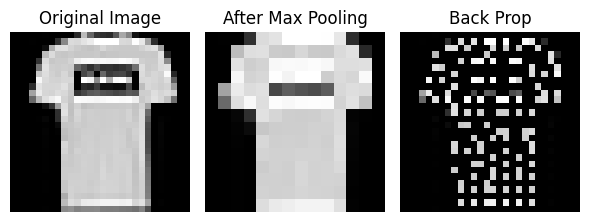

In [30]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("../CodeTest/fashion_mnist_train.npz")
X, y = data["X"], data["y"]

print(X.shape) #60000 samples, by a 28 by 28 grid. 
X = X[..., np.newaxis] #add the grayscale axis. 
print(X.shape) #60000 samples, by a 28 by 28 grid, with channel = 1 for grayscale. 
sample_batch = X[:128]
print(sample_batch.shape) #128 samples, lets pass this into our convolution layer. 

Pool = Pooling(filter_size = (2, 2), strides = (2, 2), padding = "valid", pooling_type = "max")
pool_out = Pool.forward(sample_batch)
pool_in = Pool.backward(pool_out)
sample_index = 0
original = sample_batch[sample_index, :, :, 0]
pooled1 = np.squeeze(pool_out[sample_index])  # removes all dimensions of size 1
pooled2 = np.squeeze(pool_in[sample_index])  # removes all dimensions of size 1

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(original, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(pooled1, cmap='gray')
ax[1].set_title("After Max Pooling")
ax[1].axis('off')

ax[2].imshow(pooled2, cmap = 'gray')
ax[2].set_title("Back Prop")
ax[2].axis('off')
plt.tight_layout()
plt.show()